In [ ]:
# [DÀNH RIÊNG CHO GOOGLE COLAB]
import sys, os
os.environ['MINIO_ENDPOINT'] = 'http://20.41.113.183:9000'
os.environ['MINIO_ACCESS_KEY'] = 'minioadmin'
os.environ['MINIO_SECRET_KEY'] = 'minioadmin123'
if 'SEED_PATH' in os.environ: del os.environ['SEED_PATH']
if 'google.colab' in sys.modules:
    !rm -rf /content/Lab
    !git clone -b feat-e https://github.com/nbngoc123/Lab.git /content/Lab
    os.chdir('/content/Lab/football-lake')
    sys.path.insert(0, '/content/Lab/football-lake')
    !pip install minio duckdb pandas understatapi boto3 python-dotenv
    print('Setup xong Colab!')


## 1. Import & Cấu hình

In [ ]:
"""
build_features.py — silver -> gold/features (CHỈ tầng feature).

Đặt tại: football-lake/ml/features/build_features.py
Chạy trong container airflow:
    python ml/features/build_features.py                # MinIO
    python ml/features/build_features.py --root ./lake  # thư mục local (thử nghiệm)

ĐỌC silver: matches/fd_matches, odds/fd_odds, teams/understat_team_xg,
            text/wm_pageviews (entity=team), matches/fd_matches_weather (4 nguồn sau là tùy chọn)
GHI gold/features/: feature_team_match, feature_league_position, feature_elo, feature_market,
            feature_team_xg, feature_team_attention, feature_match_context,
            feature_match_ml (1 dòng/trận + target_*), _feature_catalog.csv

CHỐNG RÒ RỈ: feature của trận T chỉ dùng dữ liệu (ngày, match_id) < T.
"""
import argparse, io, os, sys
from pathlib import Path
import duckdb
import pandas as pd
OUT = "gold/features"
SRC_TAG = "gold-features"
ROLL_FEATS = ["n_prior", "n_prior_season", "rest_days",
    "pts_l5", "gf_l5", "ga_l5", "sot_l5", "sot_against_l5", "shots_l5",
    "corners_l5", "cards_l5", "win_l5", "cs_l5",
    "pts_l10", "gf_l10", "ga_l10",
    "pts_l5_venue", "gf_l5_venue", "ga_l5_venue", "ppg_season", "gd_pg_season"]
FORM_DIFF = ["pts_l5", "gf_l5", "ga_l5", "sot_l5", "pts_l10", "ppg_season", "gd_pg_season", "pts_l5_venue"]
POS_FEATS = ["played_before", "points_before", "gd_before", "rank_before", "is_top6"]
XG_FEATS = ["xg_l5", "xga_l5", "npxg_l5", "xgd_l5", "ppda_l5", "xg_l10", "xga_l10", "xg_overperf_l10"]
XG_DIFF = ["xg_l5", "xga_l5", "xgd_l5"]
ATT_FEATS = ["pv_7d", "pv_28d", "pv_last1", "pv_ratio_7_28"]
MKT_COLS = ["mkt_p_home", "mkt_p_draw", "mkt_p_away", "mkt_margin", "mkt_n_books",
            "pin_p_home", "pin_p_draw", "pin_p_away"]
ELO_COLS = ["elo_home", "elo_away", "elo_diff", "elo_exp_home"]
CTX_COLS = ["kickoff_hour", "dow", "month", "is_weekend", "temp_c", "precip_mm", "wind_kmh", "is_raining"]
TARGET_COLS = ["target", "target_home_goals", "target_away_goals", "target_total_goals",
               "target_over25", "target_btts"]
KEY_COLS = ["match_id", "division", "season", "match_date", "home_key", "away_key",
            "home_team", "away_team", "split", "is_warm"]
WARM_MIN_MATCHES = 5

### Định nghĩa Class: LocalStore

In [ ]:
class LocalStore:
    def __init__(self, root): self.root = Path(root)
    def read_prefix(self, prefix):
        dfs = []
        for p in sorted((self.root / prefix).rglob("*.parquet")):
            d = pd.read_parquet(p); d["_key"] = p.relative_to(self.root).as_posix(); dfs.append(d)
        return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
    def write_parquet(self, key, df):
        p = self.root / key; p.parent.mkdir(parents=True, exist_ok=True)
        df.to_parquet(p, index=False, compression="zstd"); print(f"  ✓ {key}  ({len(df):,} dòng)")
    def write_csv(self, key, df):
        p = self.root / key; p.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(p, index=False); print(f"  ✓ {key}  ({len(df):,} dòng)")

### Định nghĩa Class: MinioStore

In [ ]:
class MinioStore:
    def __init__(self):
        try:
            from lake import minio_io as mio
        except ImportError:
            import os
            base = Path(__file__).resolve() if '__file__' in globals() else Path.cwd()
            for cand in (base.parents[2] if len(base.parents) >= 2 else base, Path("/opt/project"), base):
                sys.path.insert(0, str(cand))
            from lake import minio_io as mio
        self.mio = mio
    def read_prefix(self, prefix):
        dfs = []
        for key, _ in self.mio.list_keys(prefix):
            if key.endswith(".parquet"):
                d = pd.read_parquet(io.BytesIO(self.mio.read_bytes(key))); d["_key"] = key; dfs.append(d)
        return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
    def write_parquet(self, key, df):
        self.mio.put_parquet(key, df, SRC_TAG); print(f"  ✓ {key}  ({len(df):,} dòng)")
    def write_csv(self, key, df):
        self.mio.put_bytes(key, df.to_csv(index=False).encode("utf-8"), SRC_TAG, content_type="text/csv")
        print(f"  ✓ {key}  ({len(df):,} dòng)")

### Hàm: find_seed

In [ ]:
def find_seed():
    if os.environ.get("SEED_PATH"): return Path(os.environ["SEED_PATH"])
    here = Path(__file__).resolve() if '__file__' in globals() else Path.cwd()
    for parent in [here, *here.parents]:
        cand = parent / "seed" / "team_alias.csv"
        if cand.exists(): return cand
    sys.exit("Không tìm thấy seed/team_alias.csv (đặt SEED_PATH hoặc --seed)")

### Hàm: load_alias

In [ ]:
def load_alias(seed):
    frames = []
    for p in (seed, seed.with_name("team_alias_extra.csv")):
        if p.exists():
            frames.append(pd.read_csv(p, comment="#", skipinitialspace=True))
            print(f"  · alias: {p.name} ({len(frames[-1])} dòng)")
    df = pd.concat(frames, ignore_index=True)
    df.columns = df.columns.str.strip()
    df = df.dropna(subset=["source", "alias", "team_key"])
    for c in ("source", "alias", "team_key"): df[c] = df[c].astype(str).str.strip()
    df["a"] = df["alias"].str.lower()
    by_src = {(r.source, r.a): r.team_key for r in df.drop_duplicates(["source", "a"]).itertuples()}
    any_src = {}
    for r in df.itertuples(): any_src.setdefault(r.a, r.team_key)
    return by_src, any_src

### Hàm: map_team

In [ ]:
def map_team(names, source, alias, what):
    by_src, any_src = alias
    def f(n):
        if not isinstance(n, str): return None
        k = n.strip().lower()
        return by_src.get((source, k)) or any_src.get(k)
    keys = names.map(f)
    miss = sorted(set(names[keys.isna()].dropna()))
    if miss:
        print(f"  ⚠ {what}: {len(miss)} tên chưa có trong alias (source={source}) -> giữ tên gốc: {miss}")
        print(f"    thêm dòng  {source},<tên>,<team_key>  vào seed/team_alias.csv")
    return keys.fillna(names)

### Hàm: first_present

In [ ]:
def first_present(df, cands):
    for c in cands:
        if c in df.columns: return c
    return None

### Hàm: num

In [ ]:
def num(df, col):
    if col and col in df.columns:
        return pd.to_numeric(df[col], errors="coerce").astype("float64")
    return pd.Series(float("nan"), index=df.index, dtype="float64")

### Hàm: load_matches

In [ ]:
def load_matches(store, alias, division):
    raw = store.read_prefix("silver/matches/fd_matches/")
    if raw.empty: sys.exit("silver/matches/fd_matches/ trống — chạy p03 trước")
    print(f"  · fd_matches: {len(raw):,} dòng, cột: {[c for c in raw.columns if c != '_key']}")
    need = {"match_id": ["match_id"], "home_team": ["home_team"], "away_team": ["away_team"],
            "home_goals": ["home_goals"], "away_goals": ["away_goals"],
            "date": ["match_date", "date", "utc_date"], "season": ["season"]}
    col = {}
    for k, cands in need.items():
        col[k] = first_present(raw, cands)
        if not col[k]: sys.exit(f"fd_matches thiếu cột {cands}. Hiện có: {list(raw.columns)}")

    raw = raw.sort_values("_key").drop_duplicates(col["match_id"], keep="last")
    dcol = first_present(raw, ["division", "Div"])
    if dcol:
        raw = raw[raw[dcol] == division]
    else:   # silver thật không có cột division; match_id bắt đầu bằng "E0_..."
        sel = raw[raw[col["match_id"]].astype(str).str.startswith(division + "_")]
        if sel.empty:
            print(f"  ! không có match_id bắt đầu bằng '{division}_' -> KHÔNG lọc giải "
                  f"(competition={sorted(raw['competition'].unique()) if 'competition' in raw.columns else '?'})")
        else:
            raw = sel

    dt = pd.to_datetime(raw[col["date"]], errors="coerce")
    hour = pd.Series(float("nan"), index=raw.index)
    if "Time" in raw.columns:
        hour = pd.to_numeric(raw["Time"].astype(str).str.split(":").str[0], errors="coerce")
    elif dt.dt.hour.nunique() > 1:
        hour = dt.dt.hour.astype(float)

    def keys(name_col, key_col):
        if key_col in raw.columns and raw[key_col].notna().all(): return raw[key_col]
        return map_team(raw[name_col], "fd", alias, f"fd_matches.{name_col}")

    m = pd.DataFrame({
        "match_id": raw[col["match_id"]].values,
        "division": division,
        "season": raw[col["season"]].astype(str).values,
        "match_date": dt.dt.normalize().values,
        "kickoff_hour": hour.values,
        "home_team": raw[col["home_team"]].values, "away_team": raw[col["away_team"]].values,
        "home_key": keys(col["home_team"], "home_team_key").values,
        "away_key": keys(col["away_team"], "away_team_key").values,
        "home_goals": num(raw, col["home_goals"]).values, "away_goals": num(raw, col["away_goals"]).values})
    for out_c, in_c in {"h_shots": "HS", "a_shots": "AS", "h_sot": "HST", "a_sot": "AST",
                        "h_corners": "HC", "a_corners": "AC", "h_yellow": "HY", "a_yellow": "AY",
                        "h_red": "HR", "a_red": "AR"}.items():
        m[out_c] = num(raw, in_c).values
    if "HS" not in raw.columns:
        print("  ! fd_matches KHÔNG có HS/HST/HC/HY... -> feature sút/phạt/thẻ sẽ NULL "
              "(cần thêm các cột này vào silver p03 nếu muốn dùng)")

    m = m.dropna(subset=["match_date", "home_goals", "away_goals"]).copy()
    m["match_date"] = pd.to_datetime(m["match_date"]).dt.date
    m["home_goals"] = m["home_goals"].astype(int)
    m["away_goals"] = m["away_goals"].astype(int)
    # nhãn H/D/A tự tính từ tỉ số (silver thật chỉ có 'winner' = HOME_TEAM/AWAY_TEAM/DRAW)
    m["result"] = "D"
    m.loc[m.home_goals > m.away_goals, "result"] = "H"
    m.loc[m.home_goals < m.away_goals, "result"] = "A"
    if m["match_id"].duplicated().any():
        sys.exit(f"match_id trùng {int(m['match_id'].duplicated().sum())} dòng")
    m = m.sort_values(["match_date", "match_id"]).reset_index(drop=True)
    print(f"  · {len(m):,} trận đã đá ({division}), {m.match_date.min()} -> {m.match_date.max()}, "
          f"mùa: {sorted(m.season.unique())}")
    return m

### Hàm: load_odds

In [ ]:
def load_odds(store):
    o = store.read_prefix("silver/odds/fd_odds/")
    if o.empty:
        print("  ! không có fd_odds -> feature_market rỗng")
        return pd.DataFrame(columns=["match_id", "bookmaker", "odds_home", "odds_draw", "odds_away"])
    o = o.sort_values("_key").drop_duplicates(["match_id", "bookmaker"], keep="last")
    for c in ("odds_home", "odds_draw", "odds_away"): o[c] = pd.to_numeric(o[c], errors="coerce")
    return o[["match_id", "bookmaker", "odds_home", "odds_draw", "odds_away"]]

### Hàm: load_xg

In [ ]:
def load_xg(store, alias):
    u = store.read_prefix("silver/teams/understat_team_xg/")
    cols = ["team_key", "match_date", "xg", "xga", "npxg", "ppda", "scored"]
    if u.empty:
        print("  ! không có understat_team_xg -> feature_team_xg rỗng"); return pd.DataFrame(columns=cols)
    if "league" in u.columns: u = u[u["league"] == "EPL"]
    u = u.sort_values("_key")
    out = pd.DataFrame({
        "team_key": map_team(u["team_name"], "understat", alias, "understat_team_xg").values,
        "match_date": pd.to_datetime(u["date"], errors="coerce").dt.date.values,
        "xg": num(u, "xG").values, "xga": num(u, "xGA").values, "npxg": num(u, "npxG").values,
        "ppda": num(u, "ppda").values, "scored": num(u, "scored").values})
    out = out.dropna(subset=["match_date"]).drop_duplicates(["team_key", "match_date"], keep="last")
    print(f"  · understat_team_xg: {len(out):,} dòng, {out.match_date.min()} -> {out.match_date.max()}")
    return out

### Hàm: load_pageviews

In [ ]:
def load_pageviews(store, alias):
    p = store.read_prefix("silver/text/wm_pageviews/entity=team/")
    if p.empty:
        print("  ! không có wm_pageviews(team) -> feature_team_attention rỗng")
        return pd.DataFrame(columns=["team_key", "date", "views"])
    lab = "label" if "label" in p.columns else "article"
    out = pd.DataFrame({
        "team_key": map_team(p[lab], "wikidata", alias, "wm_pageviews.label").values,
        "date": pd.to_datetime(p["date"], errors="coerce").dt.date.values,
        "views": num(p, "views").values})
    out = out.dropna(subset=["date", "views"]).drop_duplicates(["team_key", "date"], keep="last")
    print(f"  · wm_pageviews(team): {len(out):,} dòng, {out.date.min()} -> {out.date.max()}")
    return out

### Hàm: load_weather

In [ ]:
def load_weather(store):
    w = store.read_prefix("silver/matches/fd_matches_weather/")
    out_cols = ["match_id", "temp_c", "precip_mm", "wind_kmh"]
    if w.empty:
        print("  ! không có fd_matches_weather -> thời tiết NULL"); return pd.DataFrame(columns=out_cols)
    w = w.sort_values("_key").drop_duplicates("match_id", keep="last")
    t = first_present(w, ["temperature_c", "temp_max", "temp"])
    r = first_present(w, ["precipitation_mm", "precipitation_sum"])
    d = first_present(w, ["windspeed_kmh", "wind_speed_max"])
    return pd.DataFrame({"match_id": w["match_id"].values, "temp_c": num(w, t).values,
                         "precip_mm": num(w, r).values, "wind_kmh": num(w, d).values})

### Hàm: win

In [ ]:
def win(n, order="match_date, match_id", by="team_key"):
    return f"(PARTITION BY {by} ORDER BY {order} ROWS BETWEEN {n} PRECEDING AND 1 PRECEDING)"

### Hàm: build_team_match

In [ ]:
def build_team_match(con):
    con.execute("""
    CREATE OR REPLACE TABLE tm AS
    SELECT match_id, match_date, season, home_key AS team_key, away_key AS opp_key, 1 AS is_home,
           home_goals AS gf, away_goals AS ga,
           CASE WHEN home_goals > away_goals THEN 3 WHEN home_goals = away_goals THEN 1 ELSE 0 END AS pts,
           (home_goals > away_goals)::INT AS win, (away_goals = 0)::INT AS clean_sheet,
           h_shots AS shots, a_shots AS shots_against, h_sot AS sot, a_sot AS sot_against, h_corners AS corners,
           CASE WHEN h_yellow IS NULL AND h_red IS NULL THEN NULL ELSE COALESCE(h_yellow,0)+2*COALESCE(h_red,0) END AS cards
    FROM m
    UNION ALL
    SELECT match_id, match_date, season, away_key, home_key, 0, away_goals, home_goals,
           CASE WHEN away_goals > home_goals THEN 3 WHEN away_goals = home_goals THEN 1 ELSE 0 END,
           (away_goals > home_goals)::INT, (home_goals = 0)::INT,
           a_shots, h_shots, a_sot, h_sot, a_corners,
           CASE WHEN a_yellow IS NULL AND a_red IS NULL THEN NULL ELSE COALESCE(a_yellow,0)+2*COALESCE(a_red,0) END
    FROM m
    """)
    con.execute(f"""
    CREATE OR REPLACE TABLE feature_team_match AS
    SELECT match_id, match_date, season, team_key, opp_key, is_home,
      COUNT(*) OVER wall AS n_prior, COUNT(*) OVER wseason AS n_prior_season,
      LEAST(date_diff('day', LAG(match_date) OVER wt, match_date), 30) AS rest_days,
      AVG(pts) OVER w5 AS pts_l5, AVG(gf) OVER w5 AS gf_l5, AVG(ga) OVER w5 AS ga_l5,
      AVG(sot) OVER w5 AS sot_l5, AVG(sot_against) OVER w5 AS sot_against_l5,
      AVG(shots) OVER w5 AS shots_l5, AVG(corners) OVER w5 AS corners_l5,
      AVG(cards) OVER w5 AS cards_l5, AVG(win) OVER w5 AS win_l5, AVG(clean_sheet) OVER w5 AS cs_l5,
      AVG(pts) OVER w10 AS pts_l10, AVG(gf) OVER w10 AS gf_l10, AVG(ga) OVER w10 AS ga_l10,
      AVG(pts) OVER wv5 AS pts_l5_venue, AVG(gf) OVER wv5 AS gf_l5_venue, AVG(ga) OVER wv5 AS ga_l5_venue,
      AVG(pts) OVER wseason AS ppg_season, AVG(gf - ga) OVER wseason AS gd_pg_season
    FROM tm
    WINDOW
      wt AS (PARTITION BY team_key ORDER BY match_date, match_id),
      wall AS (PARTITION BY team_key ORDER BY match_date, match_id ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING),
      wseason AS (PARTITION BY team_key, season ORDER BY match_date, match_id ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING),
      w5 AS {win(5)}, w10 AS {win(10)}, wv5 AS {win(5, by="team_key, is_home")}
    """)

### Hàm: build_position

In [ ]:
def build_position(con):
    con.execute("""
    CREATE OR REPLACE TABLE feature_league_position AS
    WITH dts AS (SELECT DISTINCT season, match_date FROM tm),
         tms AS (SELECT DISTINCT season, team_key FROM tm),
    pos AS (
      SELECT d.season, d.match_date, t.team_key, COUNT(x.match_id) AS played_before,
             COALESCE(SUM(x.pts),0) AS points_before, COALESCE(SUM(x.gf-x.ga),0) AS gd_before,
             COALESCE(SUM(x.gf),0) AS gf_before
      FROM dts d JOIN tms t ON t.season = d.season
      LEFT JOIN tm x ON x.season = d.season AND x.team_key = t.team_key AND x.match_date < d.match_date
      GROUP BY d.season, d.match_date, t.team_key),
    ranked AS (SELECT *, RANK() OVER (PARTITION BY season, match_date
                 ORDER BY points_before DESC, gd_before DESC, gf_before DESC) AS rk FROM pos)
    SELECT tm.match_id, tm.team_key, r.played_before, r.points_before, r.gd_before,
           CASE WHEN r.played_before > 0 THEN r.rk END AS rank_before,
           CASE WHEN r.played_before > 0 THEN (r.rk <= 6)::INT END AS is_top6
    FROM tm JOIN ranked r ON r.season = tm.season AND r.match_date = tm.match_date AND r.team_key = tm.team_key
    """)

### Hàm: compute_elo

In [ ]:
def compute_elo(df, k=20.0, hfa=65.0, keep=0.75, init=1500.0):
    ratings, last_season, out = {}, None, []
    for r in df.itertuples(index=False):
        if r.season != last_season:
            if last_season is not None:
                ratings = {t: keep * v + (1 - keep) * init for t, v in ratings.items()}
            last_season = r.season
        rh, ra = ratings.get(r.home_key, init), ratings.get(r.away_key, init)
        exp_h = 1.0 / (1.0 + 10 ** (-(rh + hfa - ra) / 400.0))
        out.append((r.match_id, rh, ra, rh - ra, exp_h))
        gd = r.home_goals - r.away_goals
        s = 1.0 if gd > 0 else 0.5 if gd == 0 else 0.0
        a = abs(gd); g = 1.0 if a <= 1 else 1.5 if a == 2 else (11 + a) / 8.0
        delta = k * g * (s - exp_h)
        ratings[r.home_key], ratings[r.away_key] = rh + delta, ra - delta
    return pd.DataFrame(out, columns=["match_id"] + ELO_COLS)

### Hàm: build_elo

In [ ]:
def build_elo(con):
    df = con.execute("SELECT match_id, season, home_key, away_key, home_goals, away_goals "
                     "FROM m ORDER BY match_date, match_id").df()
    con.register("elo_df", compute_elo(df))
    con.execute("CREATE OR REPLACE TABLE feature_elo AS SELECT * FROM elo_df")

### Hàm: build_market

In [ ]:
def build_market(con):
    con.execute("""
    CREATE OR REPLACE TABLE feature_market AS
    WITH o AS (SELECT match_id, bookmaker, 1/odds_home AS ih, 1/odds_draw AS id_, 1/odds_away AS ia
               FROM odds WHERE odds_home > 1 AND odds_draw > 1 AND odds_away > 1),
    n AS (SELECT match_id, bookmaker, ih/(ih+id_+ia) AS p_h, id_/(ih+id_+ia) AS p_d,
                 ia/(ih+id_+ia) AS p_a, ih+id_+ia-1 AS margin FROM o)
    SELECT m.match_id,
      AVG(p_h) FILTER (WHERE bookmaker NOT IN ('Avg','Max')) AS mkt_p_home,
      AVG(p_d) FILTER (WHERE bookmaker NOT IN ('Avg','Max')) AS mkt_p_draw,
      AVG(p_a) FILTER (WHERE bookmaker NOT IN ('Avg','Max')) AS mkt_p_away,
      AVG(margin) FILTER (WHERE bookmaker NOT IN ('Avg','Max')) AS mkt_margin,
      CAST(COUNT(*) FILTER (WHERE bookmaker NOT IN ('Avg','Max')) AS DOUBLE) AS mkt_n_books,
      MAX(p_h) FILTER (WHERE bookmaker = 'PS') AS pin_p_home,
      MAX(p_d) FILTER (WHERE bookmaker = 'PS') AS pin_p_draw,
      MAX(p_a) FILTER (WHERE bookmaker = 'PS') AS pin_p_away
    FROM n JOIN m USING (match_id) GROUP BY m.match_id
    """)

### Hàm: build_xg

In [ ]:
def build_xg(con):
    wu = lambda n: win(n, order="match_date")
    con.execute(f"""
    CREATE OR REPLACE TABLE feature_team_xg AS
    WITH r AS (
      SELECT team_key, match_date,
        AVG(xg) OVER w5 AS xg_l5, AVG(xga) OVER w5 AS xga_l5, AVG(npxg) OVER w5 AS npxg_l5,
        AVG(xg - xga) OVER w5 AS xgd_l5, AVG(ppda) OVER w5 AS ppda_l5,
        AVG(xg) OVER w10 AS xg_l10, AVG(xga) OVER w10 AS xga_l10,
        AVG(scored - xg) OVER w10 AS xg_overperf_l10
      FROM ux WINDOW w5 AS {wu(5)}, w10 AS {wu(10)})
    SELECT tm.match_id, tm.team_key, {", ".join("r." + c for c in XG_FEATS)}
    FROM tm JOIN r ON r.team_key = tm.team_key AND r.match_date = tm.match_date
    """)

### Hàm: build_attention

In [ ]:
def build_attention(con):
    con.execute("""
    CREATE OR REPLACE TABLE feature_team_attention AS
    WITH a AS (
      SELECT tm.match_id, tm.team_key,
        COUNT(pv.views) FILTER (WHERE pv.date >= tm.match_date - 7) AS n7,
        AVG(pv.views) FILTER (WHERE pv.date >= tm.match_date - 7) AS avg7,
        COUNT(pv.views) AS n28, AVG(pv.views) AS avg28,
        MAX(pv.views) FILTER (WHERE pv.date = tm.match_date - 1) AS last1
      FROM tm LEFT JOIN pv ON pv.team_key = tm.team_key
                          AND pv.date < tm.match_date AND pv.date >= tm.match_date - 28
      GROUP BY tm.match_id, tm.team_key)
    SELECT match_id, team_key,
      CASE WHEN n7 >= 5 THEN avg7 END AS pv_7d, CASE WHEN n28 >= 20 THEN avg28 END AS pv_28d,
      last1 AS pv_last1,
      CASE WHEN n7 >= 5 AND n28 >= 20 AND avg28 > 0 THEN avg7 / avg28 END AS pv_ratio_7_28
    FROM a
    """)

### Hàm: build_context

In [ ]:
def build_context(con, rain_mm):
    con.execute(f"""
    CREATE OR REPLACE TABLE feature_match_context AS
    SELECT m.match_id, CAST(m.kickoff_hour AS INTEGER) AS kickoff_hour,
           dayofweek(m.match_date) AS dow, month(m.match_date) AS month,
           (dayofweek(m.match_date) IN (0, 6))::INT AS is_weekend,
           w.temp_c, w.precip_mm, w.wind_kmh,
           CASE WHEN w.precip_mm IS NULL THEN NULL ELSE (w.precip_mm >= {rain_mm})::INT END AS is_raining
    FROM m LEFT JOIN wx w USING (match_id)
    """)

### Hàm: build_match_ml

In [ ]:
def build_match_ml(con):
    sel = lambda al, f, p: f"{al}.{f} AS {p}_{f}"
    form = [sel("h", f, "home") for f in ROLL_FEATS] + [sel("a", f, "away") for f in ROLL_FEATS]
    form += [f"h.{f} - a.{f} AS diff_{f}" for f in FORM_DIFF]
    pos = [sel("hp", f, "home") for f in POS_FEATS] + [sel("ap", f, "away") for f in POS_FEATS]
    pos += ["ap.rank_before - hp.rank_before AS rank_diff", "hp.points_before - ap.points_before AS points_diff"]
    xg = [sel("hx", f, "home") for f in XG_FEATS] + [sel("ax", f, "away") for f in XG_FEATS]
    xg += [f"hx.{f} - ax.{f} AS diff_{f}" for f in XG_DIFF]
    att = [sel("hv", f, "home") for f in ATT_FEATS] + [sel("av", f, "away") for f in ATT_FEATS]
    att += ["hv.pv_ratio_7_28 - av.pv_ratio_7_28 AS diff_pv_ratio_7_28"]
    con.execute(f"""
    CREATE OR REPLACE TABLE feature_match_ml AS
    SELECT m.match_id, m.division, m.season, m.match_date, m.home_key, m.away_key, m.home_team, m.away_team,
      CASE WHEN dense_rank() OVER (ORDER BY m.season DESC) = 1 THEN 'test'
           WHEN dense_rank() OVER (ORDER BY m.season DESC) = 2 THEN 'valid' ELSE 'train' END AS split,
      (h.n_prior >= {WARM_MIN_MATCHES} AND a.n_prior >= {WARM_MIN_MATCHES})::INT AS is_warm,
      {", ".join(form)}, {", ".join(pos)},
      e.elo_home, e.elo_away, e.elo_diff, e.elo_exp_home,
      {", ".join("mk." + c for c in MKT_COLS)},
      {", ".join(xg)}, {", ".join(att)},
      {", ".join("cx." + c for c in CTX_COLS)},
      m.result AS target, m.home_goals AS target_home_goals, m.away_goals AS target_away_goals,
      m.home_goals + m.away_goals AS target_total_goals,
      (m.home_goals + m.away_goals > 2)::INT AS target_over25,
      (m.home_goals > 0 AND m.away_goals > 0)::INT AS target_btts
    FROM m
    JOIN feature_team_match h ON h.match_id = m.match_id AND h.is_home = 1
    JOIN feature_team_match a ON a.match_id = m.match_id AND a.is_home = 0
    JOIN feature_league_position hp ON hp.match_id = m.match_id AND hp.team_key = m.home_key
    JOIN feature_league_position ap ON ap.match_id = m.match_id AND ap.team_key = m.away_key
    JOIN feature_elo e ON e.match_id = m.match_id
    JOIN feature_match_context cx ON cx.match_id = m.match_id
    LEFT JOIN feature_market mk ON mk.match_id = m.match_id
    LEFT JOIN feature_team_xg hx ON hx.match_id = m.match_id AND hx.team_key = m.home_key
    LEFT JOIN feature_team_xg ax ON ax.match_id = m.match_id AND ax.team_key = m.away_key
    LEFT JOIN feature_team_attention hv ON hv.match_id = m.match_id AND hv.team_key = m.home_key
    LEFT JOIN feature_team_attention av ON av.match_id = m.match_id AND av.team_key = m.away_key
    ORDER BY m.match_date, m.match_id
    """)

### Hàm: catalog

In [ ]:
def catalog(con):
    cols = [r[0] for r in con.execute("DESCRIBE feature_match_ml").fetchall()]
    grp = {}
    for f in KEY_COLS: grp[f] = "key"
    for f in TARGET_COLS: grp[f] = "target"
    for f in ELO_COLS: grp[f] = "elo"
    for f in MKT_COLS: grp[f] = "market"
    for f in CTX_COLS: grp[f] = "context"
    for p in ("home", "away"):
        for f in ROLL_FEATS: grp[f"{p}_{f}"] = "form"
        for f in POS_FEATS: grp[f"{p}_{f}"] = "position"
        for f in XG_FEATS: grp[f"{p}_{f}"] = "xg"
        for f in ATT_FEATS: grp[f"{p}_{f}"] = "attention"
    for f in FORM_DIFF: grp[f"diff_{f}"] = "form"
    for f in XG_DIFF: grp[f"diff_{f}"] = "xg"
    grp.update({"rank_diff": "position", "points_diff": "position", "diff_pv_ratio_7_28": "attention"})
    return pd.DataFrame({"column_name": cols, "feature_group": [grp.get(c, "other") for c in cols]})

### Hàm: qa

In [ ]:
def qa(con, xg_seasons):
    print("\n[QA]")
    n_m = con.execute("SELECT count(*) FROM m").fetchone()[0]
    for t in ("feature_elo", "feature_market", "feature_match_context", "feature_match_ml"):
        n, d = con.execute(f"SELECT count(*), count(DISTINCT match_id) FROM {t}").fetchone()
        assert n == d, f"{t}: match_id trùng"
        if t != "feature_market": assert n == n_m, f"{t} có {n} dòng, spine có {n_m}"
    for t in ("feature_team_match", "feature_league_position"):
        n = con.execute(f"SELECT count(*) FROM {t}").fetchone()[0]
        assert n == 2 * n_m, f"{t}: {n} dòng, kỳ vọng {2*n_m}"
    leak = con.execute("""SELECT count(*) FROM feature_team_match WHERE n_prior = 0
        AND (pts_l5 IS NOT NULL OR gf_l5 IS NOT NULL OR ppg_season IS NOT NULL)""").fetchone()[0]
    assert leak == 0, "RÒ RỈ: trận đầu của đội vẫn có feature rolling"
    print(f"  ✓ {n_m:,} trận; khóa không trùng; không rò rỉ ở trận đầu của mỗi đội")
    print(con.execute("""SELECT split, season, count(*) AS n, sum(is_warm) AS warm,
        round(avg((target='H')::INT),3) AS p_H, round(avg((target='D')::INT),3) AS p_D,
        round(avg((target='A')::INT),3) AS p_A, round(avg(target_total_goals),2) AS goals
        FROM feature_match_ml GROUP BY ALL ORDER BY season""").df().to_string(index=False))
    cov = con.execute("""SELECT
        round(avg((home_pts_l5 IS NOT NULL)::INT),2) AS form, round(avg((home_rank_before IS NOT NULL)::INT),2) AS position,
        round(avg((elo_home IS NOT NULL)::INT),2) AS elo, round(avg((mkt_p_home IS NOT NULL)::INT),2) AS market,
        round(avg((home_xg_l5 IS NOT NULL)::INT),2) AS xg, round(avg((home_pv_7d IS NOT NULL)::INT),2) AS attention,
        round(avg((temp_c IS NOT NULL)::INT),2) AS weather, round(avg((home_sot_l5 IS NOT NULL)::INT),2) AS shots
        FROM feature_match_ml WHERE is_warm = 1""").df()
    print("\n  Độ phủ feature (trận is_warm=1):"); print(cov.to_string(index=False))
    r = cov.iloc[0]
    hints = {"xg": f"Understat chỉ có {xg_seasons} — cần khớp mùa với fd_matches",
             "attention": "wm_pageviews chỉ từ 2023-01-01 hoặc label không khớp team_key",
             "weather": "fd_matches_weather chỉ có vài sân (p13 đang head(2))",
             "market": "fd_odds thiếu hoặc match_id không khớp",
             "shots": "fd_matches không có HS/HST"}
    for k, why in hints.items():
        if pd.isna(r[k]) or r[k] < 0.5: print(f"  ⚠ nhóm '{k}' phủ {r[k]}: {why}")

### Hàm: main

In [ ]:
def main():
    ap = argparse.ArgumentParser(description=__doc__, formatter_class=argparse.RawDescriptionHelpFormatter)
    ap.add_argument("--root", default=None); ap.add_argument("--division", default="E0")
    ap.add_argument("--seed", default=None)
    ap.add_argument("--rain-mm", type=float, default=0.1)
    import sys
    if 'ipykernel' in sys.modules or 'google.colab' in sys.modules:
        args = ap.parse_args([])
    else:
        args = ap.parse_args()
    a = args
    store = LocalStore(a.root) if a.root else MinioStore()
    print("[1/8] đọc silver")
    alias = load_alias(Path(a.seed) if a.seed else find_seed())
    m = load_matches(store, alias, a.division)
    odds, ux, pv, wx = load_odds(store), load_xg(store, alias), load_pageviews(store, alias), load_weather(store)
    xg_seasons = "?" if ux.empty else f"{pd.to_datetime(ux.match_date).min():%Y-%m}..{pd.to_datetime(ux.match_date).max():%Y-%m}"
    con = duckdb.connect()
    for name, df in (("m", m), ("odds", odds), ("ux", ux), ("pv", pv), ("wx", wx)): con.register(name, df)
    for title, fn in [("[2/8] form / rolling", lambda: build_team_match(con)),
                      ("[3/8] vị trí bảng trước trận", lambda: build_position(con)),
                      ("[4/8] Elo", lambda: build_elo(con)),
                      ("[5/8] market (odds)", lambda: build_market(con)),
                      ("[6/8] xG", lambda: build_xg(con)),
                      ("[7/8] attention + context", lambda: (build_attention(con), build_context(con, a.rain_mm))),
                      ("[8/8] feature_match_ml", lambda: build_match_ml(con))]:
        print(title); fn()
    qa(con, xg_seasons)
    print("\n[ghi gold/features]")
    for t in ("feature_team_match", "feature_league_position", "feature_elo", "feature_market",
              "feature_team_xg", "feature_team_attention", "feature_match_context", "feature_match_ml"):
        store.write_parquet(f"{OUT}/{t}.parquet", con.execute(f"SELECT * FROM {t}").df())
    store.write_csv(f"{OUT}/_feature_catalog.csv", catalog(con))

## ================= EDA (Exploratory Data Analysis) Tầng Gold ================
Đoạn code bên dưới sẽ query trực tiếp vào bảng `feature_match_ml.parquet` ở tầng Gold để chúng ta phân tích.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io
from lake import minio_io as mio

try:
    # Đọc trực tiếp file parquet từ Data Lake (MinIO) qua RAM
    file_bytes = mio.read_bytes('gold/features/feature_match_ml.parquet')
    df_ml = pd.read_parquet(io.BytesIO(file_bytes))
    print(f'\n[EDA] Load thành công bảng Machine Learning: {df_ml.shape[0]} dòng, {df_ml.shape[1]} cột')
    display(df_ml.head())
except Exception as e:
    print('Lỗi:', e)
    print('Chưa lấy được file từ MinIO. Hãy chạy hàm main() trước nhé!')



[EDA] Load thành công bảng Machine Learning: 380 dòng, 126 cột


,match_id,division,season,match_date,home_key,away_key,home_team,away_team,split,is_warm,...,temp_c,precip_mm,wind_kmh,is_raining,target,target_home_goals,target_away_goals,target_total_goals,target_over25,target_btts
0,E0_2024-25_20240816_ManUnited_Fulham,E0,2024-25,2024-08-16,Manchester United,Fulham,Man United,Fulham,test,0,...,NaN,NaN,NaN,<NA>,H,1,0,1,0,0
1,E0_2024-25_20240817_Arsenal_Wolves,E0,2024-25,2024-08-17,Arsenal,Wolverhampton,Arsenal,Wolves,test,0,...,NaN,NaN,NaN,<NA>,H,2,0,2,0,0
2,E0_2024-25_20240817_Everton_Brighton,E0,2024-25,2024-08-17,Everton,Brighton,Everton,Brighton,test,0,...,NaN,NaN,NaN,<NA>,A,0,3,3,1,0
3,E0_2024-25_20240817_Ipswich_Liverpool,E0,2024-25,2024-08-17,Ipswich Town,Liverpool,Ipswich,Liverpool,test,0,...,NaN,NaN,NaN,<NA>,A,0,2,2,0,0
4,E0_2024-25_20240817_Newcastle_Southampton,E0,2024-25,2024-08-17,Newcastle United,Southampton,Newcastle,Southampton,test,0,...,NaN,NaN,NaN,<NA>,H,1,0,1,0,0


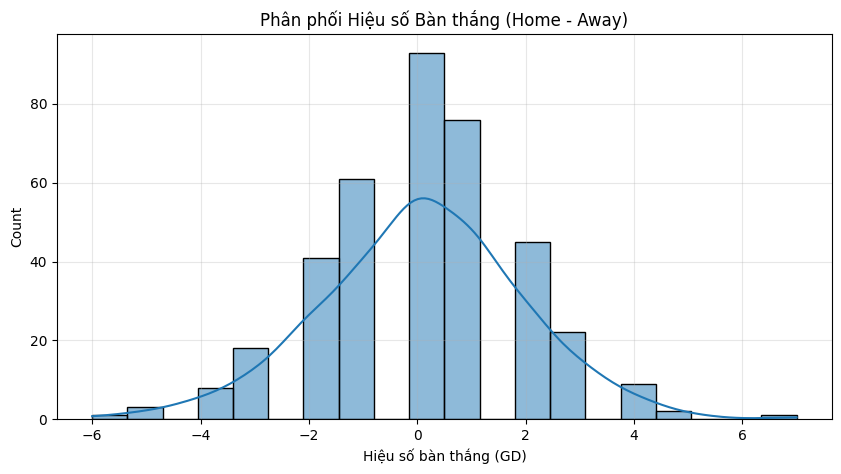

In [ ]:
# Xem độ lệch bàn thắng (target) giữa đội nhà và đội khách
if 'df_ml' in locals():
    plt.figure(figsize=(10, 5))
    sns.histplot(df_ml['target_home_goals'] - df_ml['target_away_goals'], bins=20, kde=True)
    plt.title('Phân phối Hiệu số Bàn thắng (Home - Away)')
    plt.xlabel('Hiệu số bàn thắng (GD)')
    plt.grid(alpha=0.3)
    plt.show()


/tmp/ipykernel_9041/1942038594.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ml, x='target', y='elo_diff', order=['A', 'D', 'H'], palette='viridis')


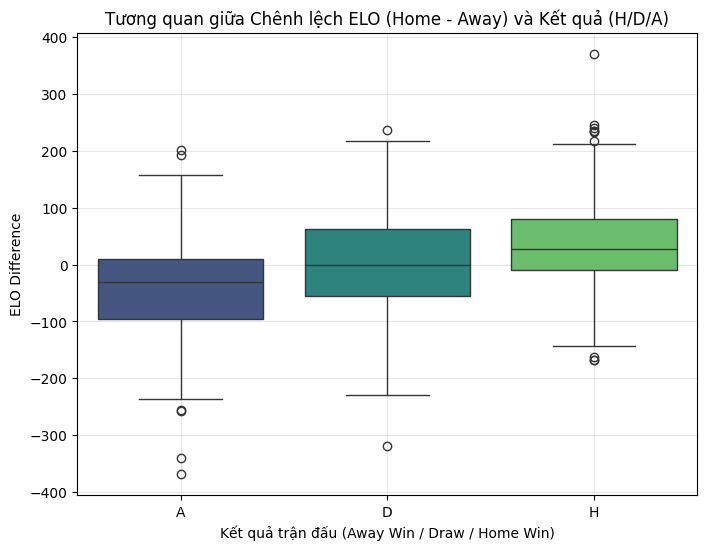

In [ ]:
# Tương quan giữa ELO chênh lệch và Kết quả trận đấu
if 'df_ml' in locals():
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df_ml, x='target', y='elo_diff', order=['A', 'D', 'H'], palette='viridis')
    plt.title('Tương quan giữa Chênh lệch ELO (Home - Away) và Kết quả (H/D/A)')
    plt.xlabel('Kết quả trận đấu (Away Win / Draw / Home Win)')
    plt.ylabel('ELO Difference')
    plt.grid(alpha=0.3)
    plt.show()


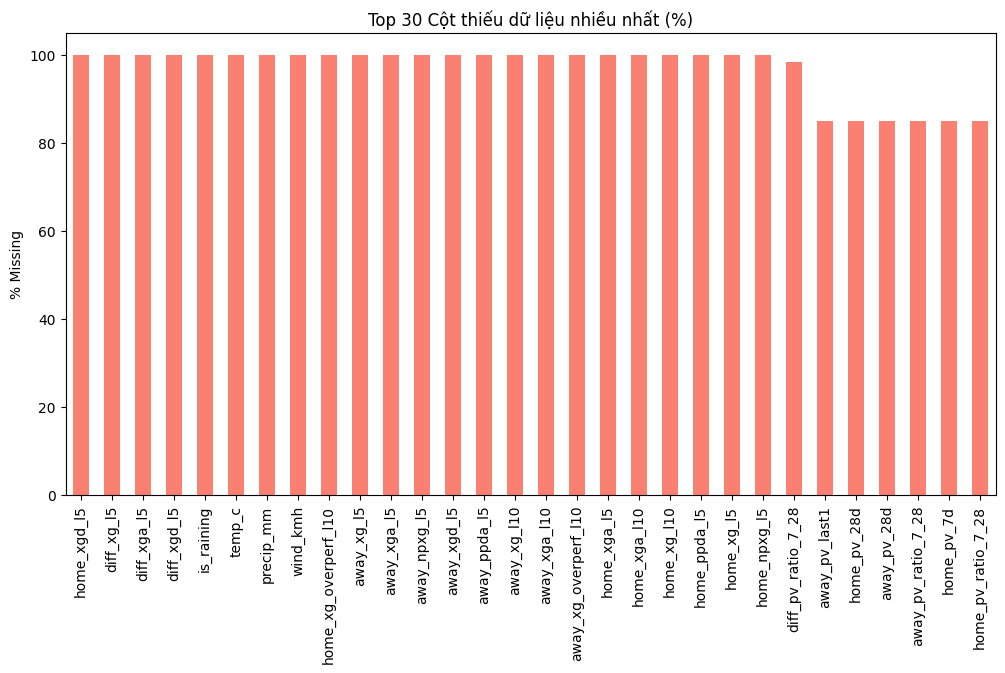

Exception ignored in atexit callback <bound method InteractiveShell.atexit_operations of <google.colab._shell.Shell object at 0x7a1cb9712660>>:
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/IPython/core/interactiveshell.py", line 3924, in atexit_operations
    self.reset(new_session=False)
  File "/usr/local/lib/python3.13/dist-packages/IPython/core/interactiveshell.py", line 1445, in reset
    self.history_manager.reset(new_session)
  File "/usr/local/lib/python3.13/dist-packages/google/colab/_history.py", line 33, in reset
    super(ColabHistoryManager, self).reset(new_session=new_session)
  File "/usr/local/lib/python3.13/dist-packages/IPython/core/history.py", line 592, in reset
    self.dir_hist[:] = [os.getcwd()]
FileNotFoundError: [Errno 2] No such file or directory


In [ ]:
# Kiểm tra Missing Values của các nhóm Features
if 'df_ml' in locals():
    missing = df_ml.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False) / len(df_ml) * 100
    if len(missing) > 0:
        plt.figure(figsize=(12, 6))
        missing[:30].plot(kind='bar', color='salmon')
        plt.title('Top 30 Cột thiếu dữ liệu nhiều nhất (%)')
        plt.ylabel('% Missing')
        plt.show()
    else:
        print('Dữ liệu siêu sạch, không có cột nào bị Missing Values!')
